# Analysis: Peak detection + alignment + CSV + plots


In [28]:
# Cell 1: imports + paths + params
from pathlib import Path
import yaml
import numpy as np
import torch
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

from infer_beat import (
    build_model,
    apply_position_mode,
    normalize_feats,
    build_beat_windows,
    slice_by_beats,
)

# paths (assume cwd = MERIX SUBMISSION/MIREX_Model)
cfg_path = Path("config_beat_mazurka_level6.yaml")
ckpt_path = Path("check/beat_mazurka/level_6/beat_mazurka_L6_20260130_141117/best.pt")
input_dir = Path("beat_data_mazurka_performer_levels")
pattern = "M06-3_*_L6.npz"

# pred peak params (lower if too few peaks)
pred_height = 0.05
pred_min_dist = 6
pred_prominence = 0.03

# true peak params
use_true_binary = True  # True if boundary_probs are 0/1
true_height = 0.05
true_min_dist = 6
true_prominence = 0.03

# assignment radius (beats)
assign_radius = 6

# output


In [59]:
# Cell 2: main analysis function (with output_head switch)
def analyze_boundary_dist(
    config_path,
    ckpt_path,
    input_dir,
    pattern,
    output_head="dist",
    pred_height=0.05,
    pred_min_dist=6,
    pred_prominence=0.03,
    use_true_binary=True,
    true_height=0.05,
    true_min_dist=6,
    true_prominence=0.03,
    assign_radius=6,
    do_plots=True,
):
    cfg = yaml.safe_load(Path(config_path).read_text())
    ckpt_path = Path(ckpt_path)
    perf_map_path = ckpt_path.parent / 'performer_map.yaml'
    perf_map_from_ckpt = None
    if perf_map_path.exists():
        perf_map_from_ckpt = yaml.safe_load(perf_map_path.read_text())
    files = sorted(Path(input_dir).glob(pattern))
    performer_cond = cfg.get("model", {}).get("performer_cond", False)
    perf_map = {}
    if performer_cond:
        if perf_map_from_ckpt:
            perf_map = {k: int(v) for k, v in perf_map_from_ckpt.items()}
            cfg.setdefault("model", {})["performer_vocab_size"] = max(perf_map.values()) + 1
        else:
            import re
            perf_re = cfg.get("data", {}).get("performer_id_regex", r"(pid[^_]+)")
            pattern_re = re.compile(perf_re)
            tokens = []
            for f in files:
                m = pattern_re.search(f.stem)
                if m:
                    tokens.append(m.group(1))
            tokens = sorted(set(tokens))
            perf_map = {t: i + 1 for i, t in enumerate(tokens)}
            cfg.setdefault("model", {})["performer_vocab_size"] = len(perf_map) + 1
    if not files:
        raise RuntimeError("No matching npz files")

    sample = np.load(files[0])
    input_dim = sample["note_feats"].shape[1]

    model = build_model(cfg, input_dim=input_dim)
    state = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state, strict=False)
    model.eval()

    position_mode = cfg.get("data", {}).get("position_mode", "absolute")
    value_ranges = cfg.get("data", {}).get("value_ranges")
    window_beats = cfg.get("data", {}).get("beat_sequence_length")
    window_stride = cfg.get("data", {}).get("beat_stride")
    max_len = cfg.get("data", {}).get("max_len")
    include_empty_beats = cfg.get("model", {}).get("include_empty_beats", False)

    def infer_probs_for_npz(npz_path):
        performer_id = 0
        if perf_map:
            import re
            perf_re = cfg.get("data", {}).get("performer_id_regex", r"(pid[^_]+)")
            m = re.search(perf_re, Path(npz_path).stem)
            if m:
                performer_id = perf_map.get(m.group(1), 0)
        npz = np.load(npz_path)
        note_feats = npz["note_feats"]
        beat_ids = npz["beat_ids"]
        if beat_ids.size == 0:
            return np.array([])

        num_beats = int(beat_ids.max()) + 1

        if window_beats is None:
            feats = apply_position_mode(note_feats, position_mode)
            if value_ranges:
                feats = normalize_feats(feats, value_ranges)
            feats_t = torch.tensor(feats).unsqueeze(0)
            beat_ids_t = torch.tensor(beat_ids).unsqueeze(0)
            attn_mask = beat_ids_t >= 0
            with torch.no_grad():
                logits, _ = model(
                    feats_t,
                    beat_ids=beat_ids_t,
                    num_beats=num_beats,
                    attn_mask=attn_mask,
                    labels=None,
                    output_head=output_head,
                    performer_ids=torch.tensor([performer_id]),
                )
                probs = torch.sigmoid(logits).squeeze(0).cpu().numpy()
            if not include_empty_beats:
                valid_beats = np.zeros(num_beats, dtype=bool)
                valid_beats[np.unique(beat_ids[beat_ids >= 0])] = True
                probs = np.where(valid_beats, probs, 0.0)
            return probs

        windows = build_beat_windows(num_beats, int(window_beats), int(window_stride))
        sum_probs = np.zeros(num_beats, dtype=np.float64)
        count_probs = np.zeros(num_beats, dtype=np.int64)

        for start, end in windows:
            feats, ids = slice_by_beats(note_feats, beat_ids, start, end, max_len)
            if feats is None or ids is None or feats.shape[0] == 0:
                continue
            feats = apply_position_mode(feats, position_mode)
            if value_ranges:
                feats = normalize_feats(feats, value_ranges)
            feats_t = torch.tensor(feats).unsqueeze(0)
            beat_ids_t = torch.tensor(ids).unsqueeze(0)
            attn_mask = beat_ids_t >= 0
            with torch.no_grad():
                logits, _ = model(
                    feats_t,
                    beat_ids=beat_ids_t,
                    num_beats=end - start,
                    attn_mask=attn_mask,
                    labels=None,
                    output_head=output_head,
                    performer_ids=torch.tensor([performer_id]),
                )
                probs_win = torch.sigmoid(logits).squeeze(0).cpu().numpy()

            idx = np.arange(start, end)
            if include_empty_beats:
                sum_probs[idx] += probs_win
                count_probs[idx] += 1
            else:
                valid = np.zeros(end - start, dtype=bool)
                if ids.size > 0:
                    valid[np.unique(ids[ids >= 0])] = True
                sum_probs[idx[valid]] += probs_win[valid]
                count_probs[idx[valid]] += 1

        probs = np.zeros(num_beats, dtype=np.float64)
        seen = count_probs > 0
        probs[seen] = sum_probs[seen] / count_probs[seen]
        return probs.astype(np.float32)

    pred_probs = infer_probs_for_npz(files[0])
    pred_peaks, _ = find_peaks(
        pred_probs,
        distance=pred_min_dist,
        height=pred_height,
        prominence=pred_prominence,
    )

    num_beats = len(np.load(files[0])["boundary_probs"])
    true_counts = np.zeros(num_beats, dtype=int)
    for p in files:
        labels = np.load(p)["boundary_probs"].astype(float)
        if use_true_binary:
            true_peaks = np.where(labels > 0.5)[0]
        else:
            true_peaks, _ = find_peaks(
                labels,
                distance=true_min_dist,
                height=true_height,
                prominence=true_prominence,
            )
        true_counts[true_peaks] += 1

    true_prob = true_counts / len(files)
    true_avg_peaks = true_counts.sum() / max(len(files), 1)

    pred_peak_strengths = pred_probs[pred_peaks] if pred_peaks.size > 0 else np.array([])
    if pred_peak_strengths.size > 0:
        rel = pred_peak_strengths / pred_peak_strengths.sum()
        pred_peak_strengths_scaled = rel * true_avg_peaks  # sum equals avg true peak count
    else:
        pred_peak_strengths_scaled = np.array([])

    # assign pred peaks to nearest true peaks
    true_peaks = np.where(true_counts > 0)[0]
    assignments = {int(t): [] for t in true_peaks}
    for pk in pred_peaks:
        if true_peaks.size == 0:
            continue
        nearest = int(true_peaks[np.argmin(np.abs(true_peaks - pk))])
        if abs(nearest - pk) <= assign_radius:
            assignments[nearest].append((int(pk), float(pred_probs[pk])))

    rows = []
    pred_sum_total = 0.0
    for t in true_peaks:
        assigned = assignments[int(t)]
        if assigned:
            strengths = np.array([s for _, s in assigned], dtype=float)
            pred_sum = float(strengths.sum())
            pred_max = float(strengths.max())
            pred_cnt = len(strengths)
            pred_list = " ".join(str(p) for p, _ in assigned)
        else:
            pred_sum = 0.0
            pred_max = 0.0
            pred_cnt = 0
            pred_list = ""
        pred_sum_total += pred_sum
        rows.append([int(t), int(true_counts[int(t)]), pred_cnt, pred_sum, pred_max, pred_list])

    rows_rel = []
    for t, true_cnt, pred_cnt, pred_sum, pred_max, pred_list in rows:
        true_rel = true_cnt / max(true_counts.sum(), 1)
        pred_rel = pred_sum / max(pred_sum_total, 1e-9)
        rows_rel.append([t, true_cnt, true_rel, pred_cnt, pred_sum, pred_max, pred_rel, pred_list])


    if do_plots:
        # true distribution vs pred peaks
        plt.figure(figsize=(12, 6))
        plt.bar(np.arange(num_beats), true_prob, width=1.0, alpha=0.6, label="True peak frequency")
        for i, pk in enumerate(pred_peaks):
            plt.axvline(pk, color="red", linewidth=1.0, alpha=0.8, label="Pred peaks" if i == 0 else None)
        plt.title("True peak distribution vs pred peaks")
        plt.xlabel("Beat index")
        plt.ylabel("True peak frequency (across performers)")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # pred curve + peaks
        plt.figure(figsize=(12, 4))
        plt.plot(pred_probs, label=f"Pred probs ({output_head})", linewidth=1.2)
        plt.scatter(pred_peaks, pred_probs[pred_peaks], color="red", s=20, label="Pred peaks")
        plt.title("Pred curve with peaks")
        plt.xlabel("Beat index")
        plt.ylabel("Pred prob")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # aligned comparison
        true_rel = np.array([r[2] for r in rows_rel], dtype=float)
        pred_rel = np.array([r[6] for r in rows_rel], dtype=float)
        tp = np.array([r[0] for r in rows_rel], dtype=int)
        plt.figure(figsize=(12, 5))
        plt.plot(tp, true_rel, label="True peak rel (freq)", linewidth=1.5)
        plt.plot(tp, pred_rel, label="Pred peak rel (aligned)", linewidth=1.5)
        plt.title("Aligned Pred vs True Relative Strength (by true peaks)")
        plt.xlabel("True peak beat index")
        plt.ylabel("Relative strength")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # pred curve + true relative strength (line)
        plt.figure(figsize=(12, 5))
        plt.plot(pred_probs, label=f"Pred curve ({output_head})", linewidth=1.2, color="C0")
        plt.plot(true_peaks, true_rel, label="True relative strength", linewidth=1.2, color="C1")
        plt.title("Pred Curve vs True Relative Strength")
        plt.xlabel("Beat index")
        plt.ylabel("Value")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "pred_peak_positions": pred_peaks,
        "pred_peak_strengths_scaled": pred_peak_strengths_scaled,
        "pred_peak_strengths": pred_peak_strengths,
        "pred_probs": pred_probs,
        "pred_peaks": pred_peaks,
        "pred_peak_count": int(len(pred_peaks)),
        "true_counts": true_counts,
        "true_prob": true_prob,
        "true_avg_peaks": float(true_avg_peaks),
        "rows_rel": rows_rel,
    }


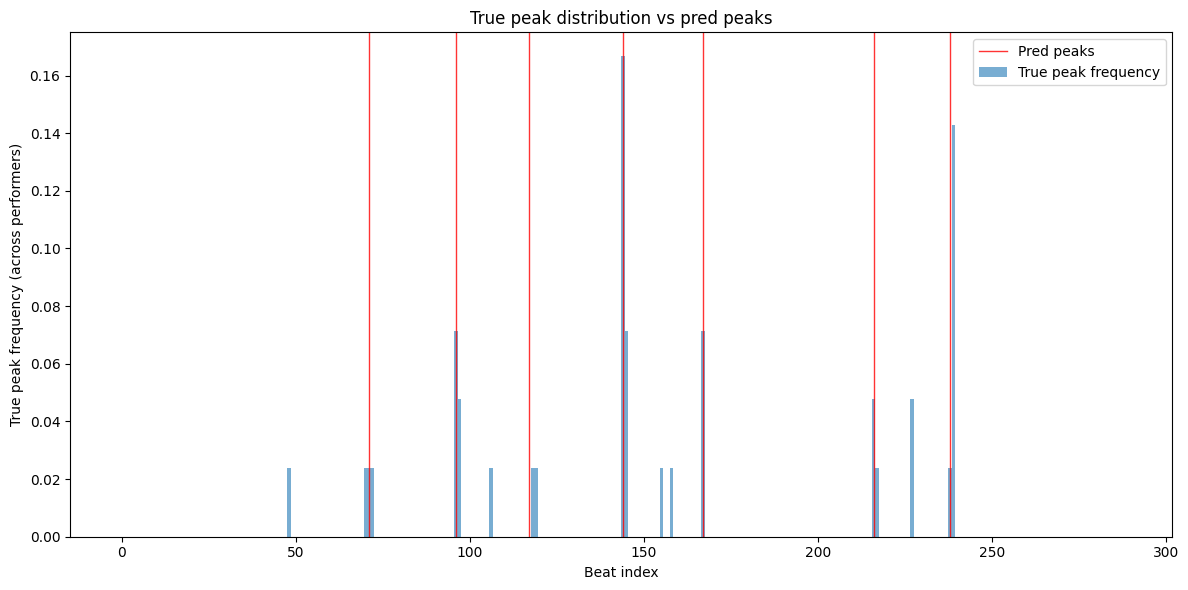

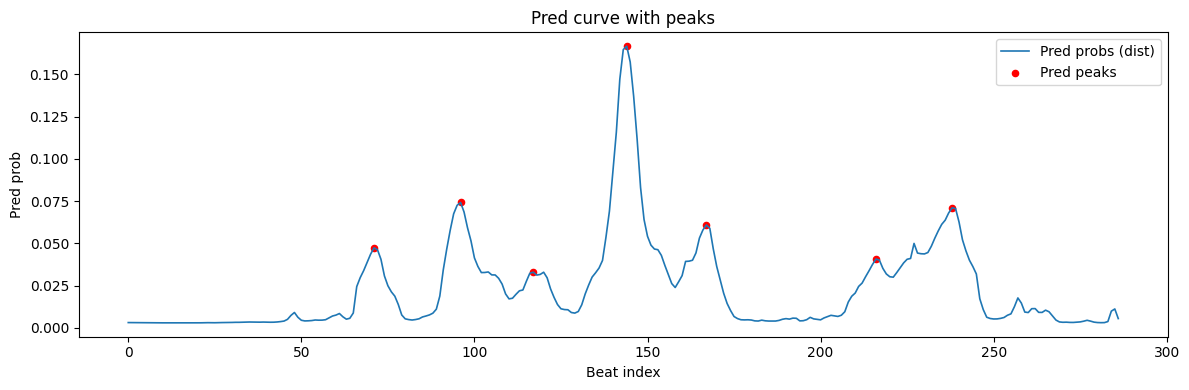

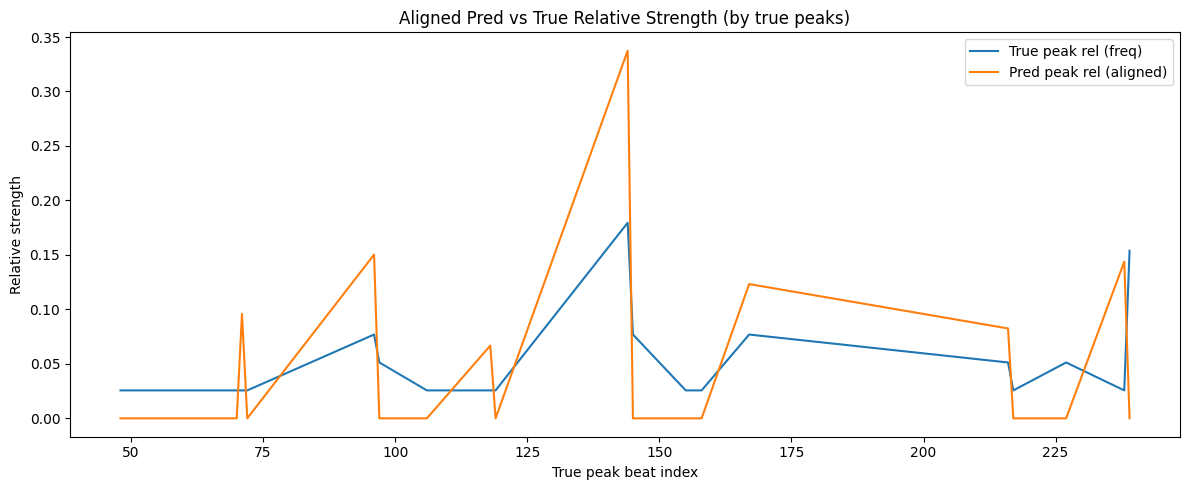

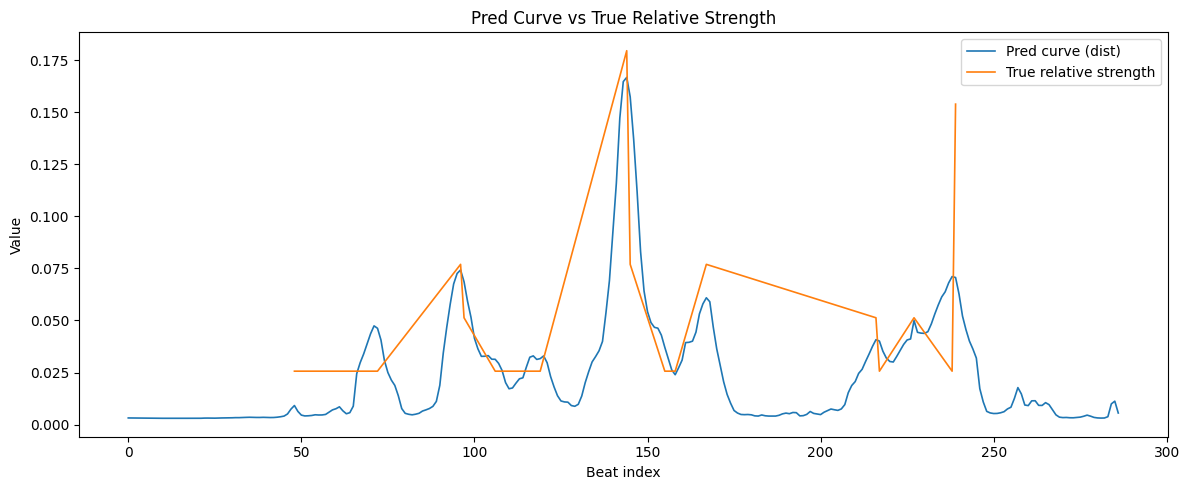

true_avg_peaks: 0.9285714285714286 pred_peak_count: 7
pred_peak_strengths_scaled sum: 0.9285714216530324
pred_peak_strengths_scaled: [0.08908684 0.13953655 0.06199589 0.31333043 0.11444035 0.07661959
 0.13356177]
pred_peak_positions: [ 71  96 117 144 167 216 238]


In [60]:
# l6 dist
result = analyze_boundary_dist(
    config_path = Path("config_beat_mazurka_level6.yaml"),
    ckpt_path = Path("check/beat_mazurka/level_6/beat_mazurka_L6_20260130_141117/best.pt"),
    input_dir = Path("beat_data_mazurka_performer_levels"),
    pattern="M06-2_*_L6.npz",
    output_head="dist",
    pred_height=0.03,
    pred_min_dist=3,
    pred_prominence=0.01,
    use_true_binary=use_true_binary,
    true_height=0.05,
    true_min_dist=6,
    true_prominence=0.03,
    assign_radius=6,
    do_plots=True,
)

print("true_avg_peaks:", result["true_avg_peaks"], "pred_peak_count:", result["pred_peak_count"])

if result['pred_peak_strengths_scaled'].size > 0:
    print('pred_peak_strengths_scaled sum:', result['pred_peak_strengths_scaled'].sum())
    print('pred_peak_strengths_scaled:', result['pred_peak_strengths_scaled'])
if result['pred_peak_positions'].size > 0:
    print('pred_peak_positions:', result['pred_peak_positions'])


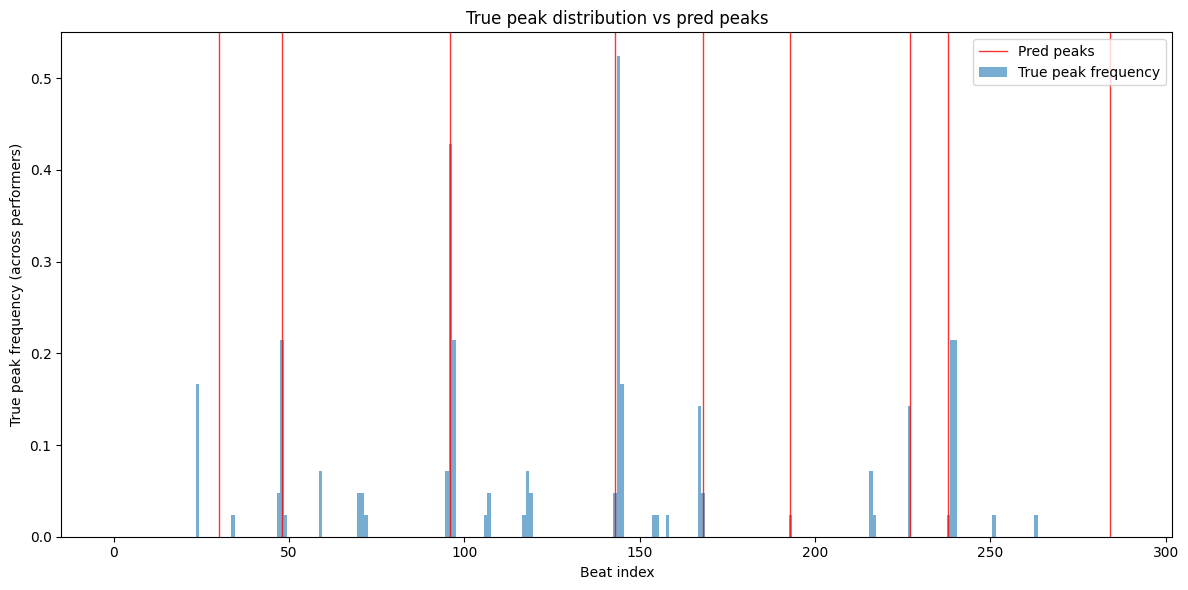

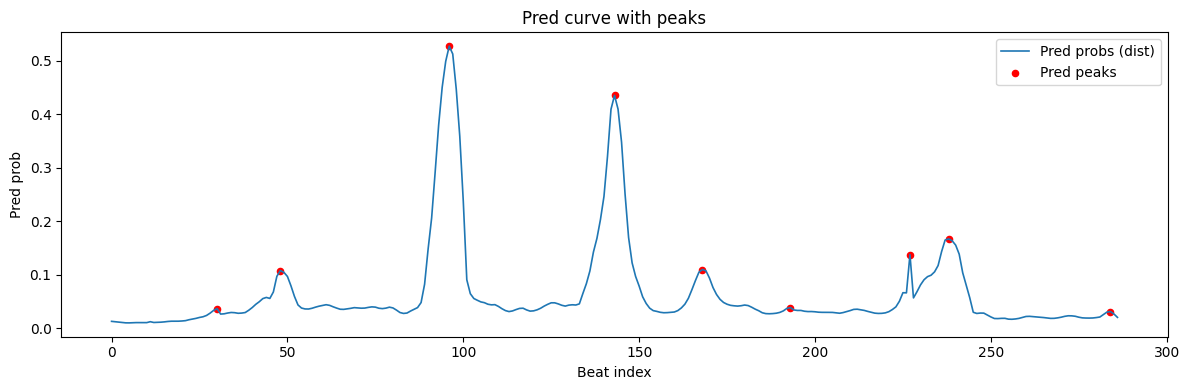

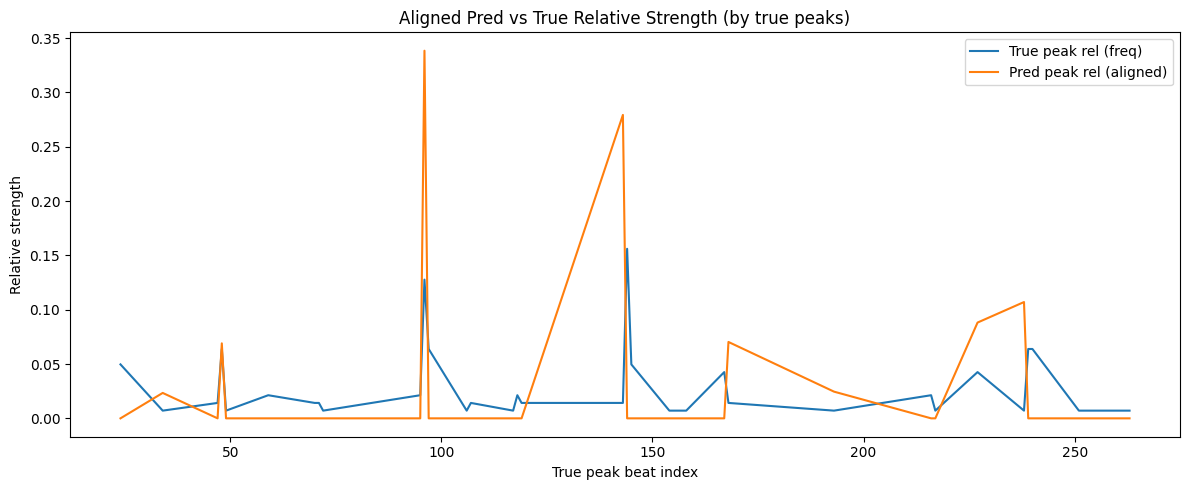

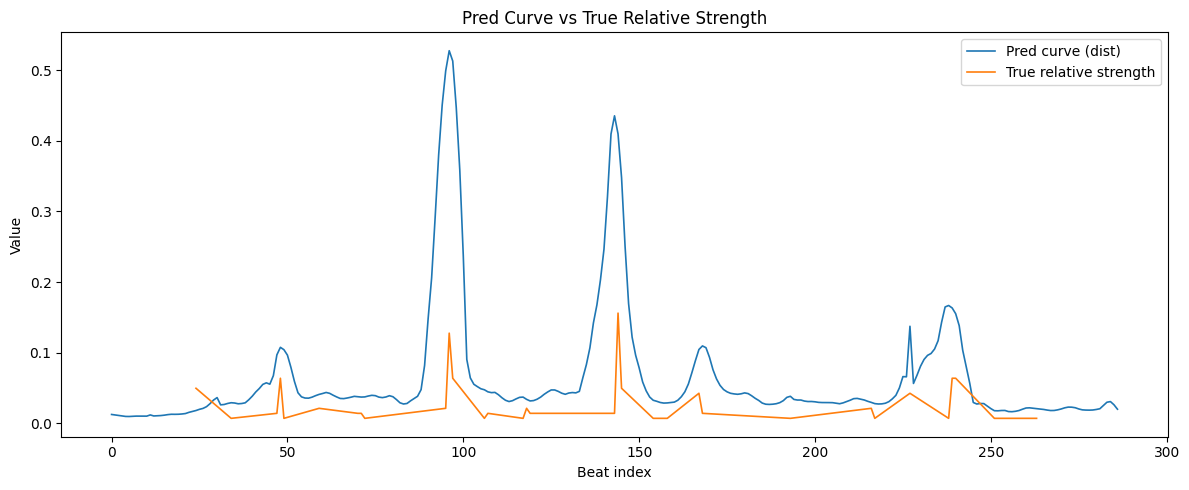

true_avg_peaks: 3.357142857142857 pred_peak_count: 9
pred_peak_strengths_scaled sum: 3.357143013472004
pred_peak_strengths_scaled: [0.07698496 0.22722714 1.1138019  0.91922879 0.23141996 0.08089896
 0.29018464 0.35231812 0.06507854]
pred_peak_positions: [ 30  48  96 143 168 193 227 238 284]


In [61]:
# l5 dist
result = analyze_boundary_dist(
    config_path = Path("config_beat_mazurka_level5.yaml"),
    ckpt_path = Path("check/beat_mazurka/level_5/beat_mazurka_L5_20260130_190152/best.pt"),
    input_dir = Path("beat_data_mazurka_performer_levels"),
    pattern="M06-2_*_L5.npz",
    output_head="dist",
    pred_height=0.03,
    pred_min_dist=3,
    pred_prominence=0.01,
    use_true_binary=use_true_binary,
    true_height=0.05,
    true_min_dist=6,
    true_prominence=0.03,
    assign_radius=6,
    do_plots=True,
)

print("true_avg_peaks:", result["true_avg_peaks"], "pred_peak_count:", result["pred_peak_count"])

if result['pred_peak_strengths_scaled'].size > 0:
    print('pred_peak_strengths_scaled sum:', result['pred_peak_strengths_scaled'].sum())
    print('pred_peak_strengths_scaled:', result['pred_peak_strengths_scaled'])
if result['pred_peak_positions'].size > 0:
    print('pred_peak_positions:', result['pred_peak_positions'])


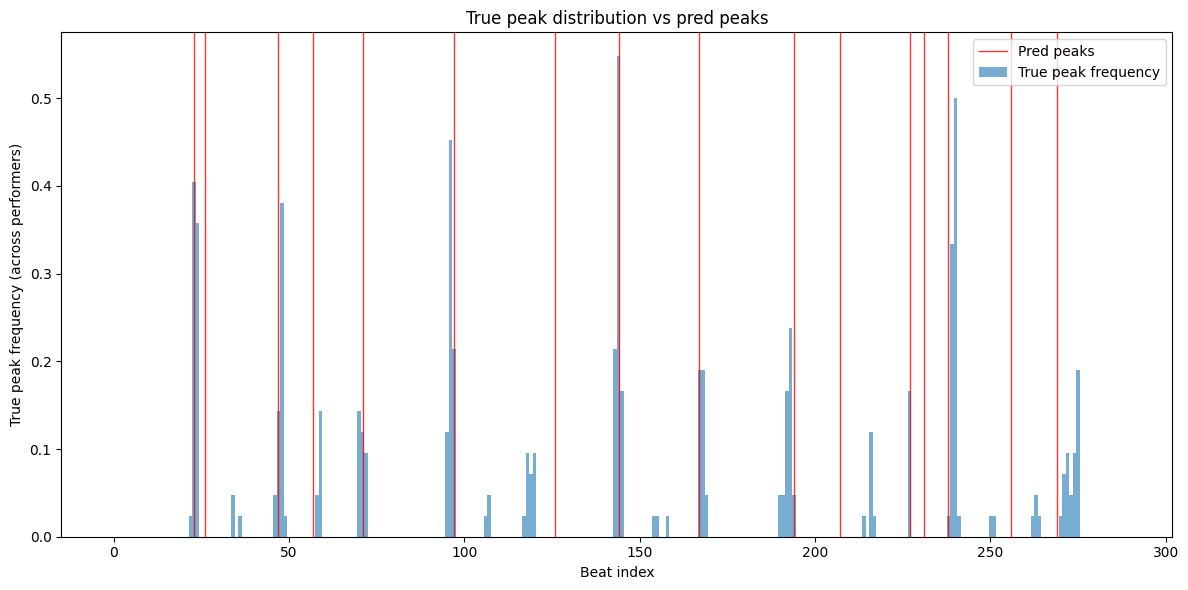

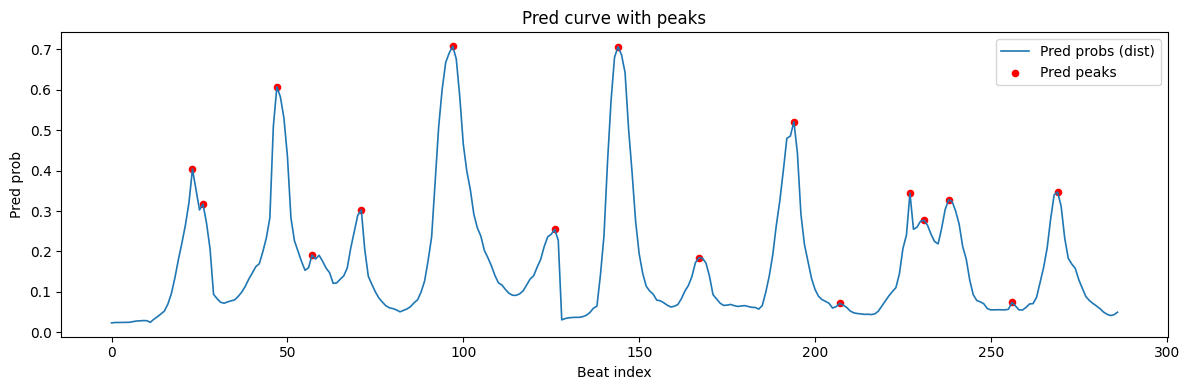

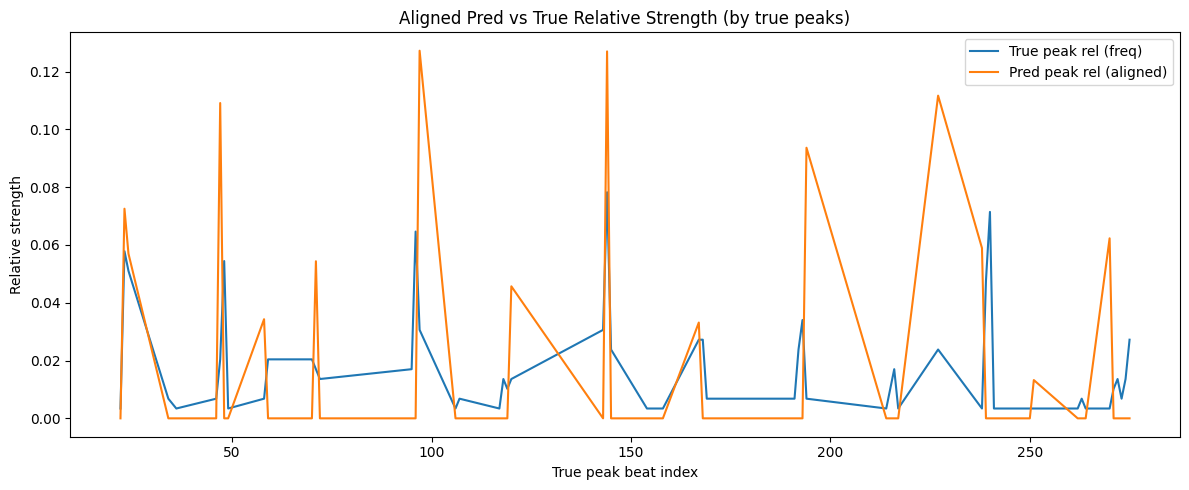

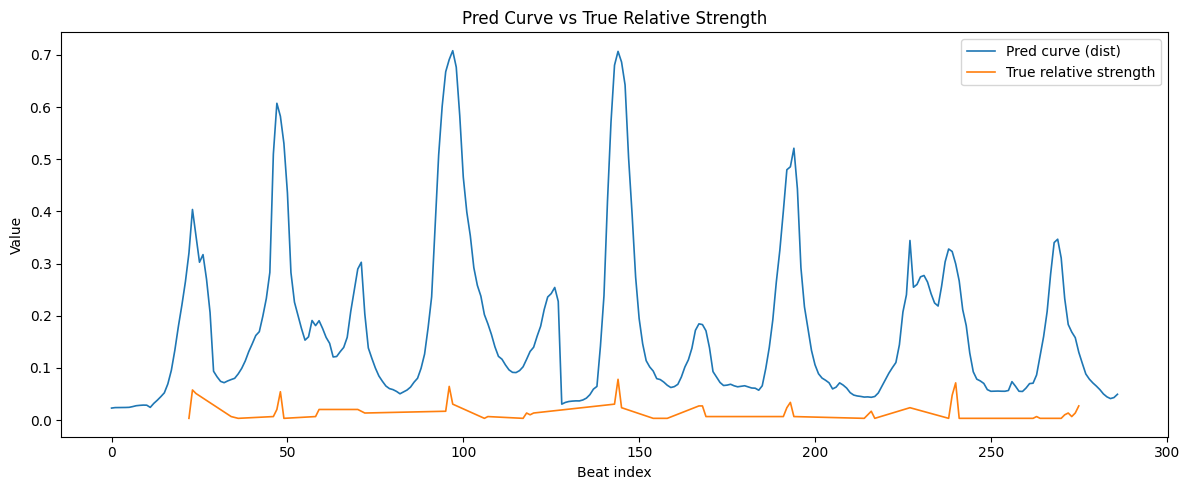

true_avg_peaks: 7.0 pred_peak_count: 16
pred_peak_strengths_scaled sum: 6.999999810941517
pred_peak_strengths_scaled: [0.50127529 0.39386848 0.75400648 0.23707973 0.37565832 0.87912174
 0.31571666 0.87751372 0.22910561 0.64705221 0.08866109 0.4275046
 0.34417604 0.40722623 0.09151443 0.43051918]
pred_peak_positions: [ 23  26  47  57  71  97 126 144 167 194 207 227 231 238 256 269]


In [62]:
# l4 dist
result = analyze_boundary_dist(
    config_path = Path("config_beat_mazurka_level4.yaml"),
    ckpt_path = Path("check/beat_mazurka/level_4/beat_mazurka_L4_20260130_190213/best.pt"),
    input_dir = Path("beat_data_mazurka_performer_levels"),
    pattern="M06-2_*_L4.npz",
    output_head="dist",
    pred_height=0.03,
    pred_min_dist=3,
    pred_prominence=0.01,
    use_true_binary=use_true_binary,
    true_height=0.05,
    true_min_dist=6,
    true_prominence=0.03,
    assign_radius=6,
    do_plots=True,
)

print("true_avg_peaks:", result["true_avg_peaks"], "pred_peak_count:", result["pred_peak_count"])

if result['pred_peak_strengths_scaled'].size > 0:
    print('pred_peak_strengths_scaled sum:', result['pred_peak_strengths_scaled'].sum())
    print('pred_peak_strengths_scaled:', result['pred_peak_strengths_scaled'])
if result['pred_peak_positions'].size > 0:
    print('pred_peak_positions:', result['pred_peak_positions'])


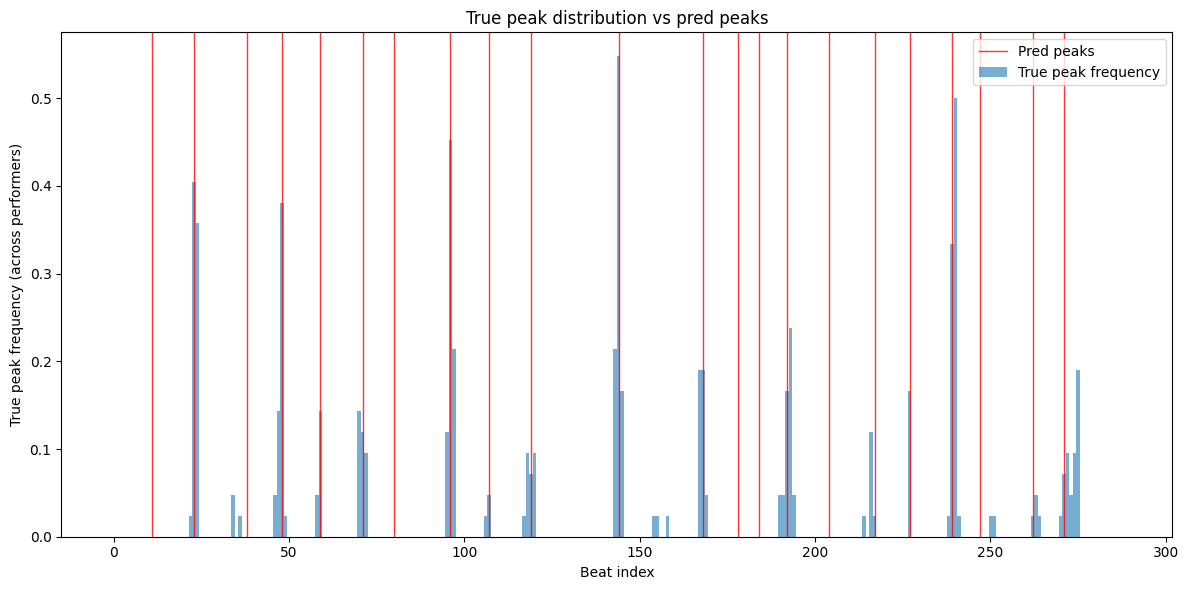

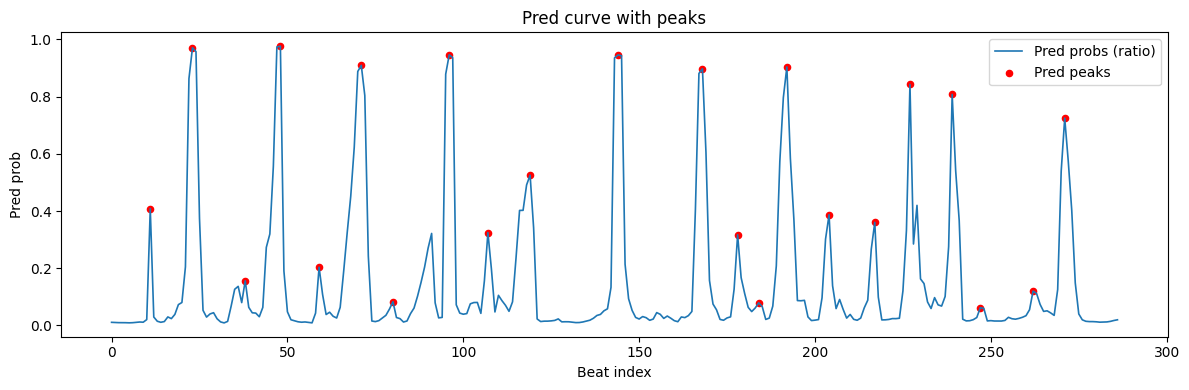

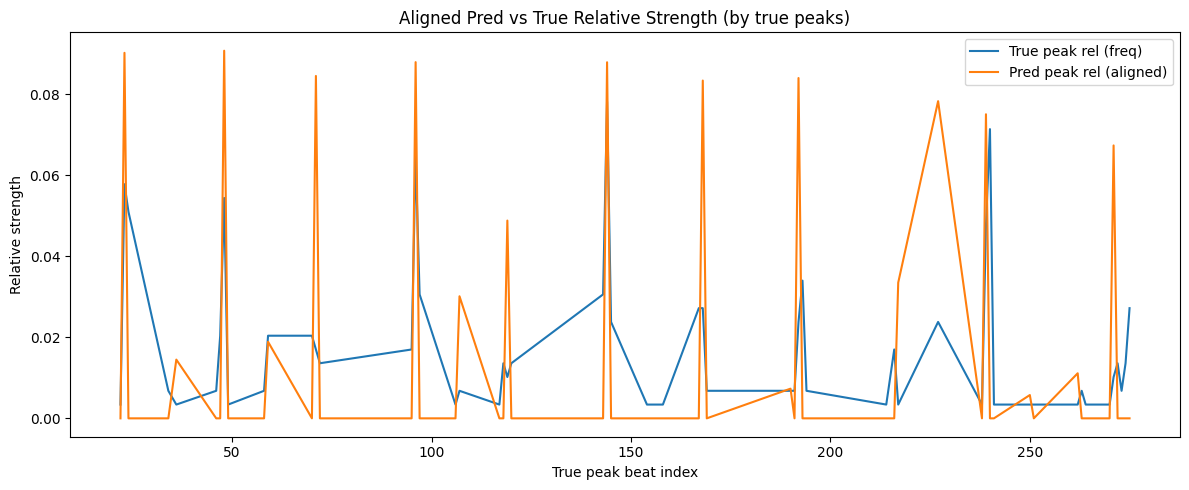

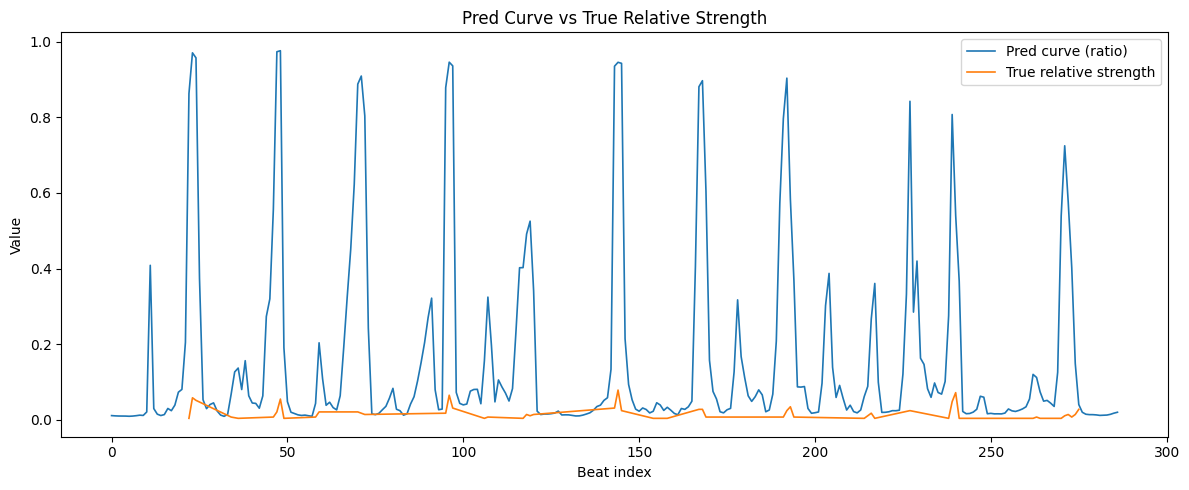

true_avg_peaks: 7.0 pred_peak_count: 22
pred_peak_strengths_scaled sum: 6.999998842831701
pred_peak_strengths_scaled: [0.23927268 0.56870012 0.09138791 0.57198374 0.11913893 0.53271627
 0.04849874 0.55421647 0.18997406 0.30770455 0.55402287 0.52553366
 0.18570271 0.04618958 0.52947254 0.22673687 0.21115313 0.49352202
 0.47310725 0.03624475 0.07011983 0.42460016]
pred_peak_positions: [ 11  23  38  48  59  71  80  96 107 119 144 168 178 184 192 204 217 227
 239 247 262 271]


In [63]:
# l4 ratio
result = analyze_boundary_dist(
    config_path = Path("config_beat_mazurka_level4_ratio.yaml"),
    ckpt_path = Path("check/beat_mazurka/level_4/beat_mazurka_L4_20260131_163418/best.pt"),
    input_dir = Path("beat_data_mazurka_performer_levels"),
    pattern="M06-2_*_L4.npz",
    output_head="ratio",
    pred_height=0.05,
    pred_min_dist=6,
    pred_prominence=0.03,
    use_true_binary=use_true_binary,
    true_height=0.05,
    true_min_dist=6,
    true_prominence=0.03,
    assign_radius=6,
    do_plots=True,
)

print("true_avg_peaks:", result["true_avg_peaks"], "pred_peak_count:", result["pred_peak_count"])

if result['pred_peak_strengths_scaled'].size > 0:
    print('pred_peak_strengths_scaled sum:', result['pred_peak_strengths_scaled'].sum())
    print('pred_peak_strengths_scaled:', result['pred_peak_strengths_scaled'])
if result['pred_peak_positions'].size > 0:
    print('pred_peak_positions:', result['pred_peak_positions'])


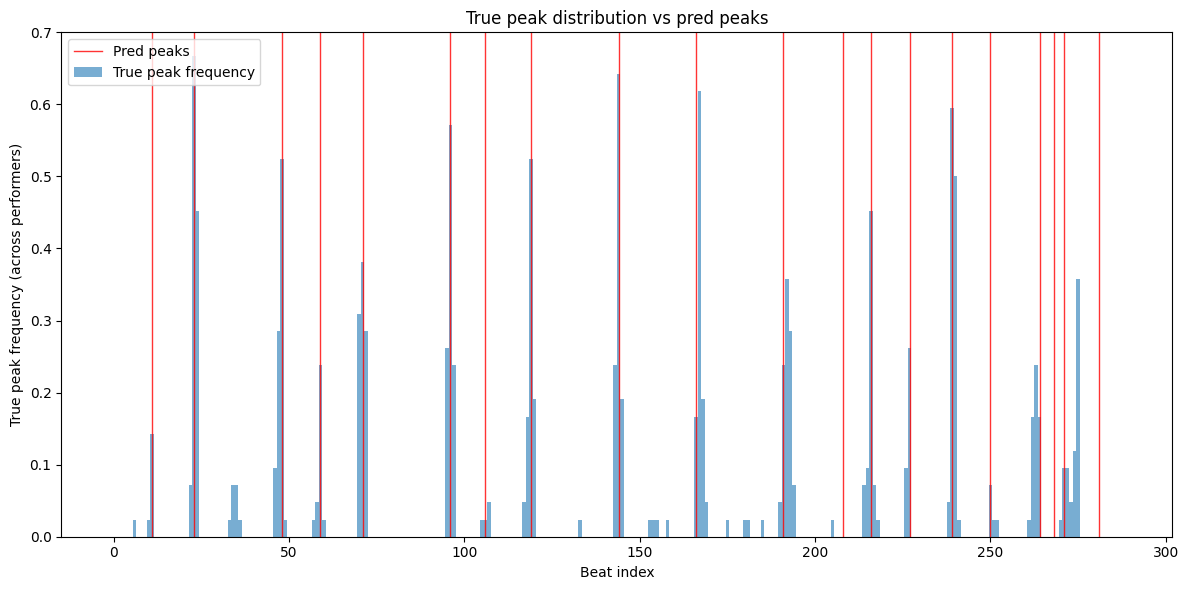

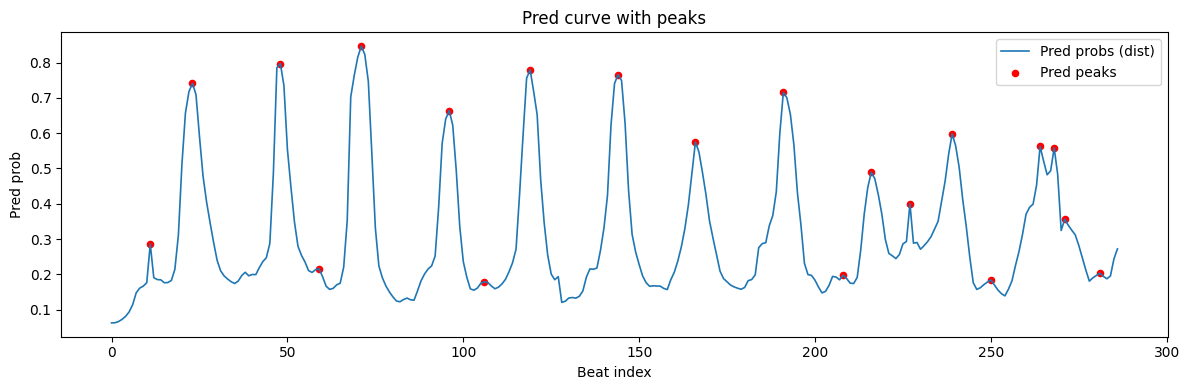

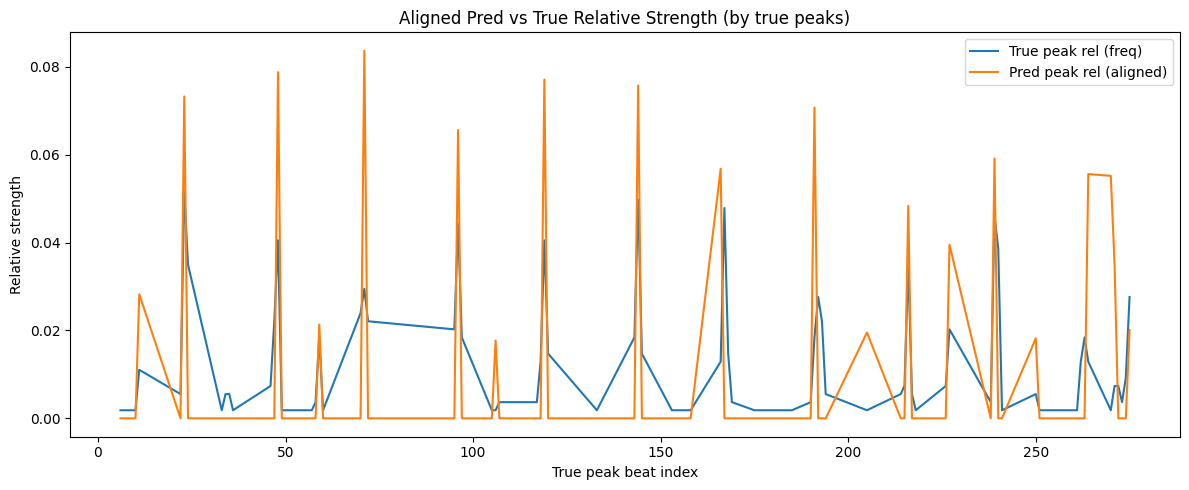

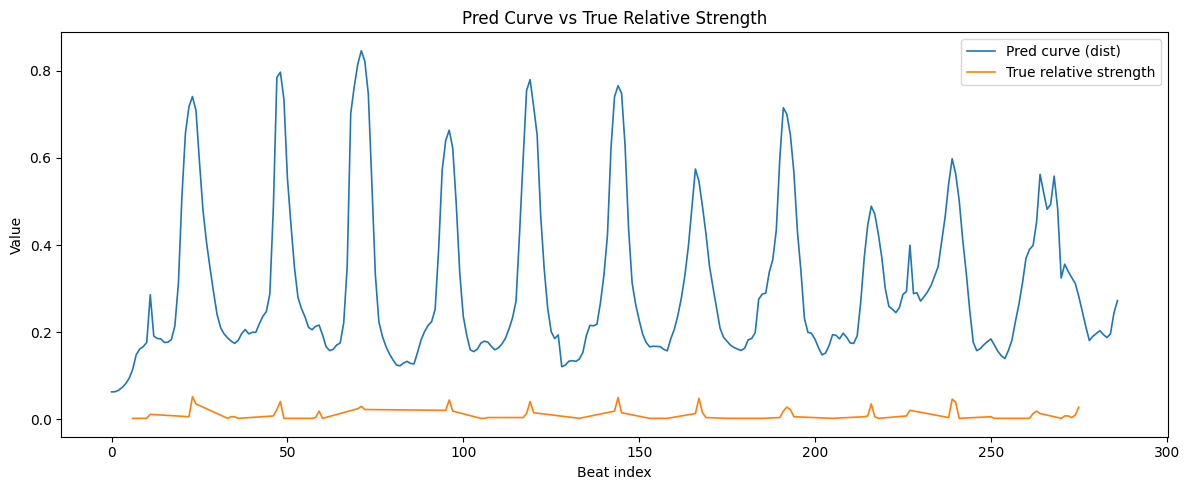

true_avg_peaks: 12.928571428571429 pred_peak_count: 20
pred_peak_strengths_scaled sum: 12.928570585724499
pred_peak_strengths_scaled: [0.36528644 0.94724937 1.01891968 0.2761324  1.08192427 0.84854217
 0.22904033 0.99692686 0.97919895 0.73455603 0.91449383 0.25251446
 0.62530727 0.51090111 0.76468569 0.23546798 0.71881801 0.71364081
 0.45509337 0.25987157]
pred_peak_positions: [ 11  23  48  59  71  96 106 119 144 166 191 208 216 227 239 250 264 268
 271 281]


In [ ]:
# l3 dist
result = analyze_boundary_dist(
    config_path = Path("config_beat_mazurka_level3.yaml"),
    ckpt_path = Path("check/beat_mazurka/level_3/beat_mazurka_L3_20260130_231129/best.pt"),
    input_dir = Path("beat_data_mazurka_performer_levels"),
    pattern="M06-2_*_L3.npz",
    output_head="dist",
    pred_height=0.03,
    pred_min_dist=3,
    pred_prominence=0.01,
    use_true_binary=use_true_binary,
    true_height=0.05,
    true_min_dist=6,
    true_prominence=0.03,
    assign_radius=6,
    do_plots=True,
)

print("true_avg_peaks:", result["true_avg_peaks"], "pred_peak_count:", result["pred_peak_count"])

if result['pred_peak_strengths_scaled'].size > 0:
    print('pred_peak_strengths_scaled sum:', result['pred_peak_strengths_scaled'].sum())
    print('pred_peak_strengths_scaled:', result['pred_peak_strengths_scaled'])
if result['pred_peak_positions'].size > 0:
    print('pred_peak_positions:', result['pred_peak_positions'])


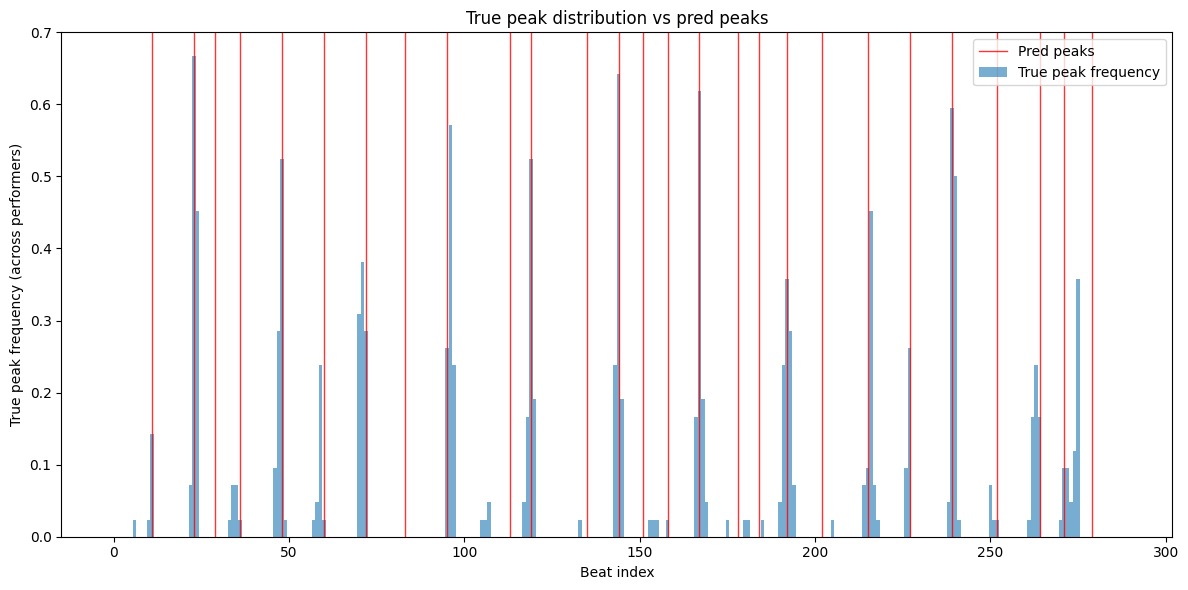

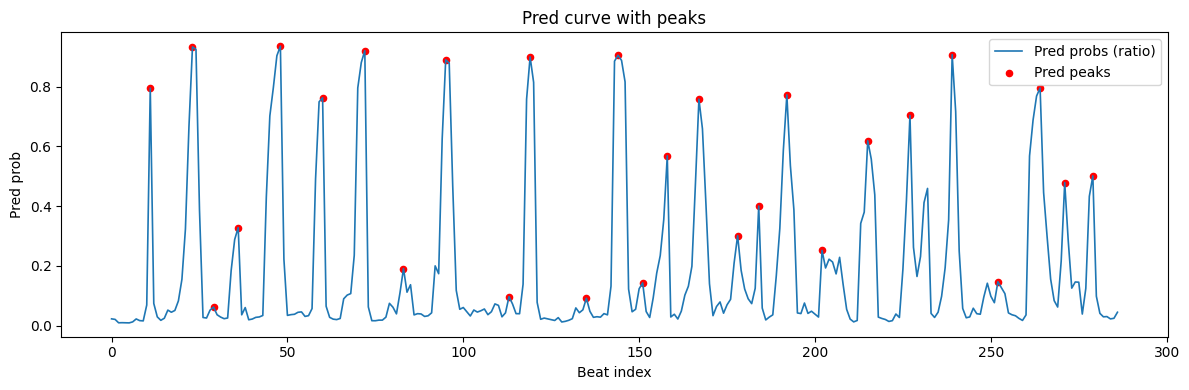

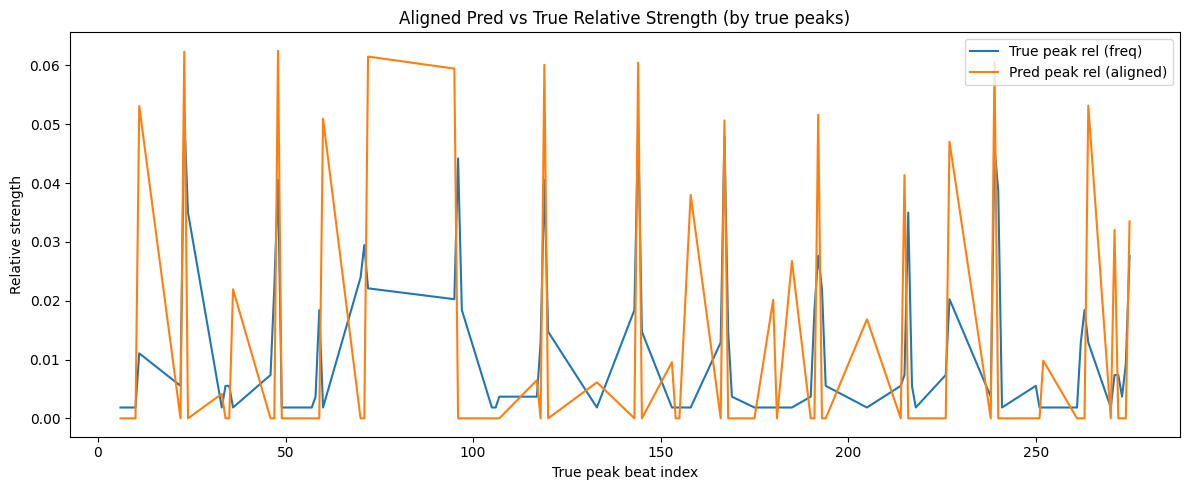

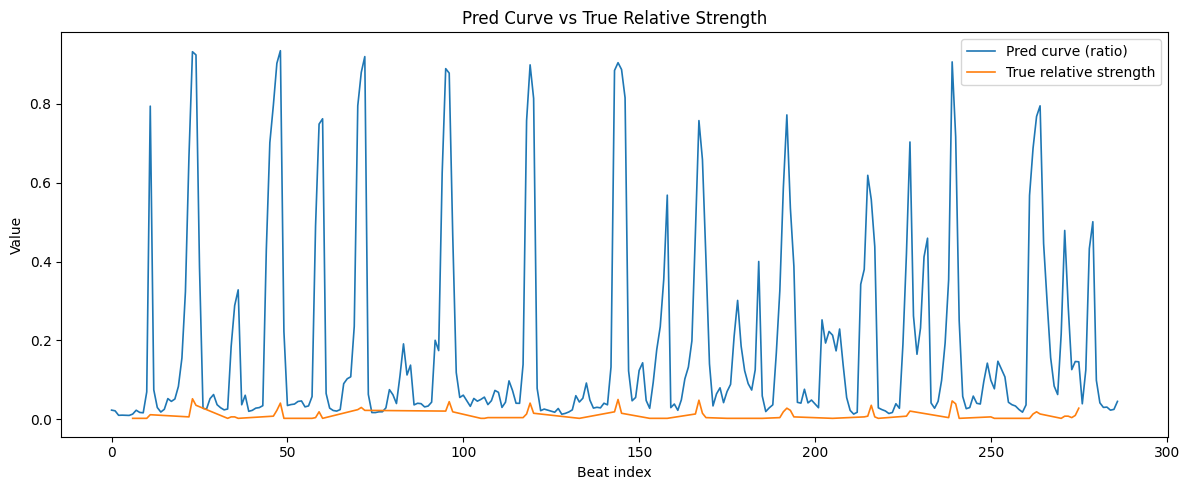

true_avg_peaks: 12.928571428571429 pred_peak_count: 27
pred_peak_strengths_scaled sum: 12.928571711527184
pred_peak_strengths_scaled: [0.67772474 0.79563893 0.0531146  0.27988625 0.79783823 0.65045686
 0.78510946 0.1628763  0.75901347 0.08273969 0.7672243  0.07805206
 0.77190393 0.12188016 0.48501285 0.64649745 0.25703698 0.34134783
 0.65881631 0.2149021  0.5279873  0.6001638  0.77365112 0.1252495
 0.67845681 0.40853075 0.42745993]
pred_peak_positions: [ 11  23  29  36  48  60  72  83  95 113 119 135 144 151 158 167 178 184
 192 202 215 227 239 252 264 271 279]


In [65]:
# l3 ratio
result = analyze_boundary_dist(
    config_path = Path("config_beat_mazurka_level3_ratio.yaml"),
    ckpt_path = Path("check/beat_mazurka/level_3/beat_mazurka_L3_20260131_163241/best.pt"),
    input_dir = Path("beat_data_mazurka_performer_levels"),
    pattern="M06-2_*_L3.npz",
    output_head="ratio",
    pred_height=0.05,
    pred_min_dist=6,
    pred_prominence=0.03,
    use_true_binary=use_true_binary,
    true_height=0.05,
    true_min_dist=6,
    true_prominence=0.03,
    assign_radius=6,
    do_plots=True,
)

print("true_avg_peaks:", result["true_avg_peaks"], "pred_peak_count:", result["pred_peak_count"])

if result['pred_peak_strengths_scaled'].size > 0:
    print('pred_peak_strengths_scaled sum:', result['pred_peak_strengths_scaled'].sum())
    print('pred_peak_strengths_scaled:', result['pred_peak_strengths_scaled'])
if result['pred_peak_positions'].size > 0:
    print('pred_peak_positions:', result['pred_peak_positions'])


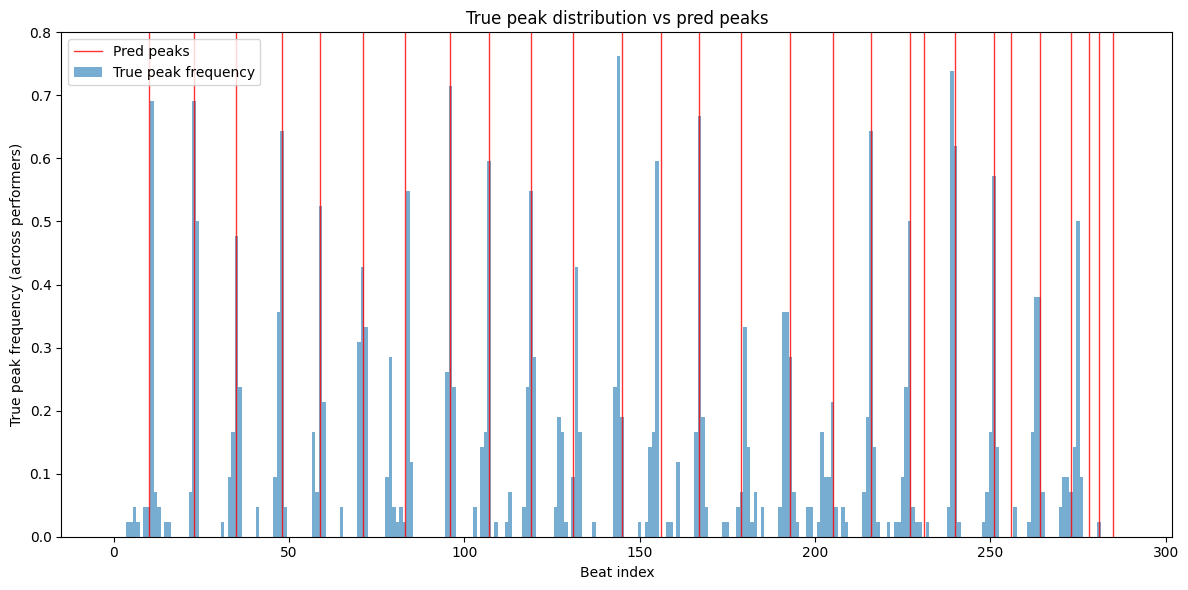

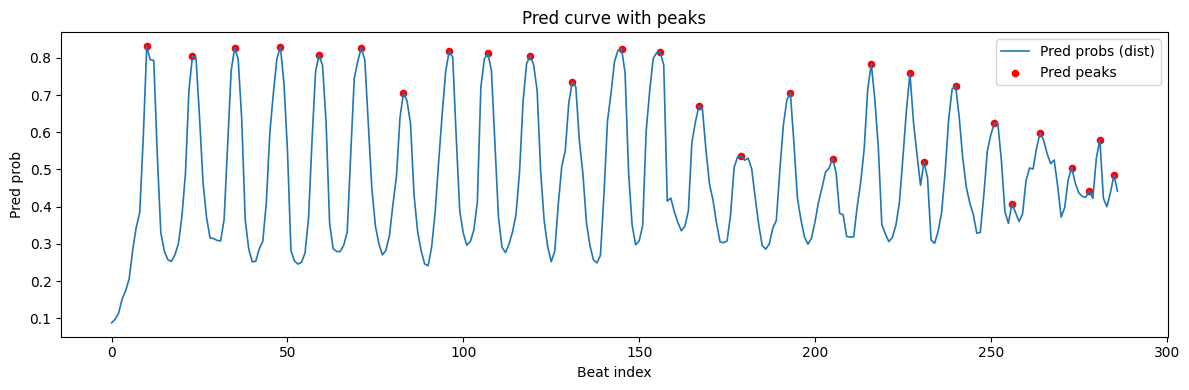

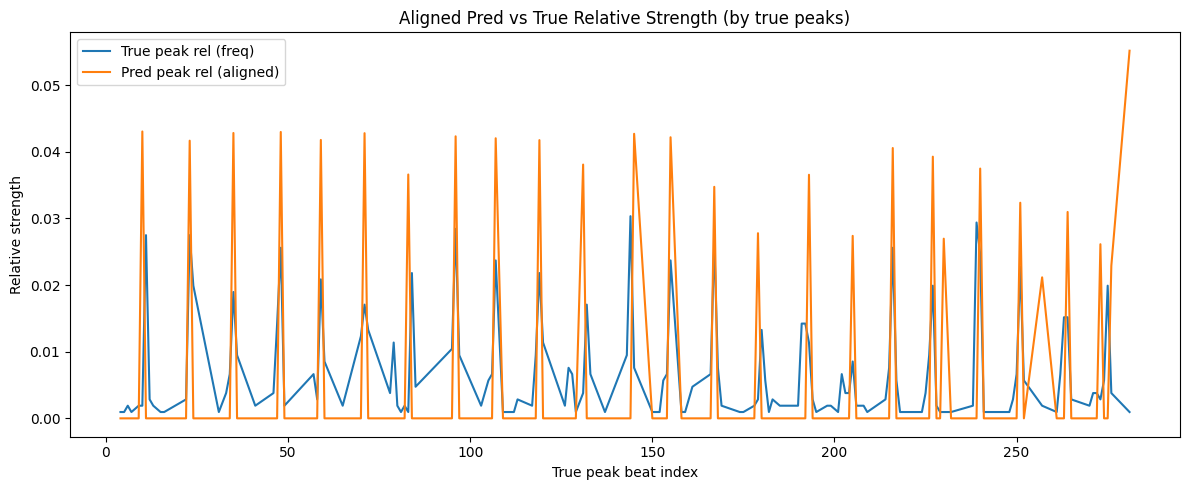

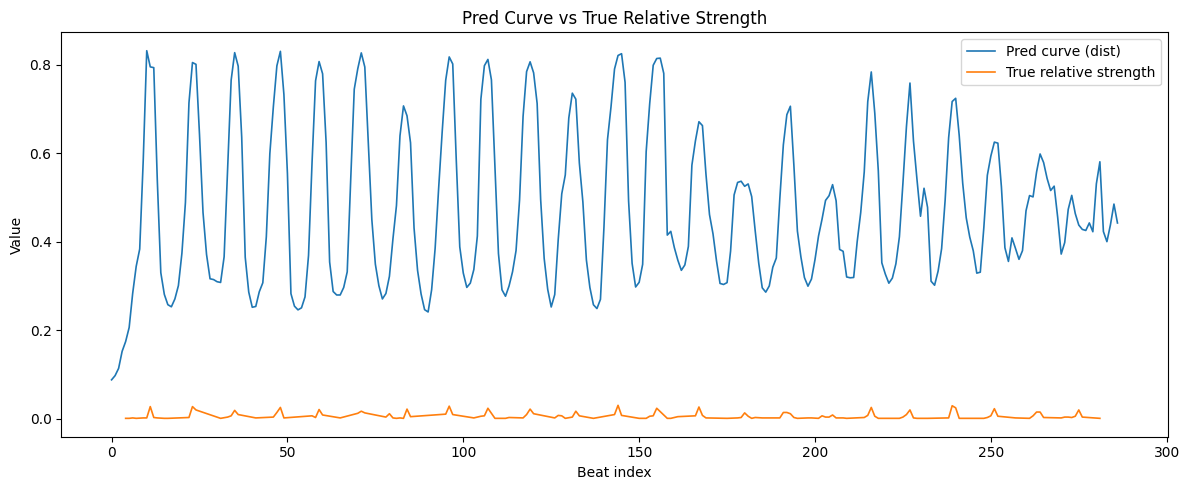

true_avg_peaks: 25.11904761904762 pred_peak_count: 28
pred_peak_strengths_scaled sum: 25.119047010805282
pred_peak_strengths_scaled: [1.08116517 1.04643519 1.07546519 1.07935335 1.04927717 1.0747425
 0.91897754 1.06288187 1.0555838  1.0485631  0.95643244 1.07242837
 1.05936801 0.87254272 0.69773135 0.91803261 0.68774214 1.01878
 0.98620946 0.67711161 0.94135327 0.81262075 0.53137562 0.77780865
 0.65624333 0.57526812 0.75492667 0.63062701]
pred_peak_positions: [ 10  23  35  48  59  71  83  96 107 119 131 145 156 167 179 193 205 216
 227 231 240 251 256 264 273 278 281 285]


In [66]:
# l2 dist
result = analyze_boundary_dist(
    config_path = Path("config_beat_mazurka_level2.yaml"),
    ckpt_path = Path("check/beat_mazurka/level_2/beat_mazurka_L2_20260130_234527/best.pt"),
    input_dir = Path("beat_data_mazurka_performer_levels"),
    pattern="M06-2_*_L2.npz",
    output_head="dist",
    pred_height=0.03,
    pred_min_dist=3,
    pred_prominence=0.01,
    use_true_binary=use_true_binary,
    true_height=0.05,
    true_min_dist=6,
    true_prominence=0.03,
    assign_radius=6,
    do_plots=True,
)

print("true_avg_peaks:", result["true_avg_peaks"], "pred_peak_count:", result["pred_peak_count"])

if result['pred_peak_strengths_scaled'].size > 0:
    print('pred_peak_strengths_scaled sum:', result['pred_peak_strengths_scaled'].sum())
    print('pred_peak_strengths_scaled:', result['pred_peak_strengths_scaled'])
if result['pred_peak_positions'].size > 0:
    print('pred_peak_positions:', result['pred_peak_positions'])


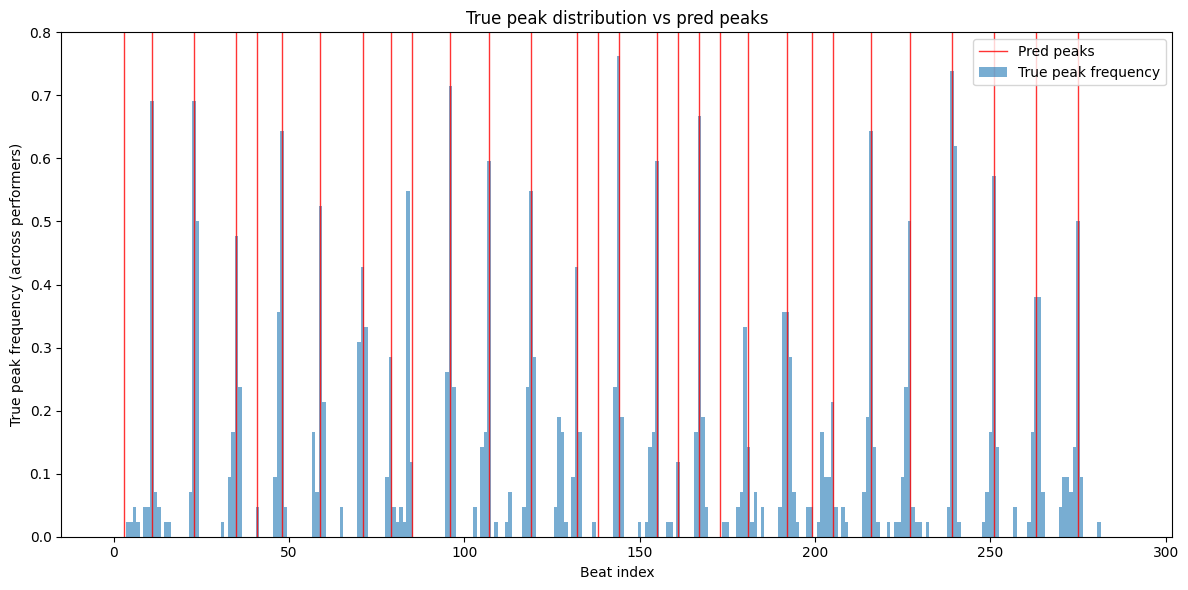

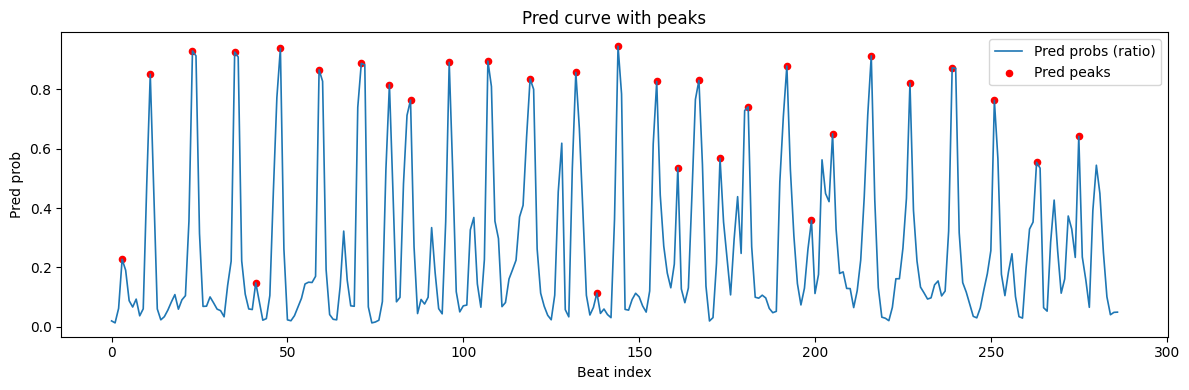

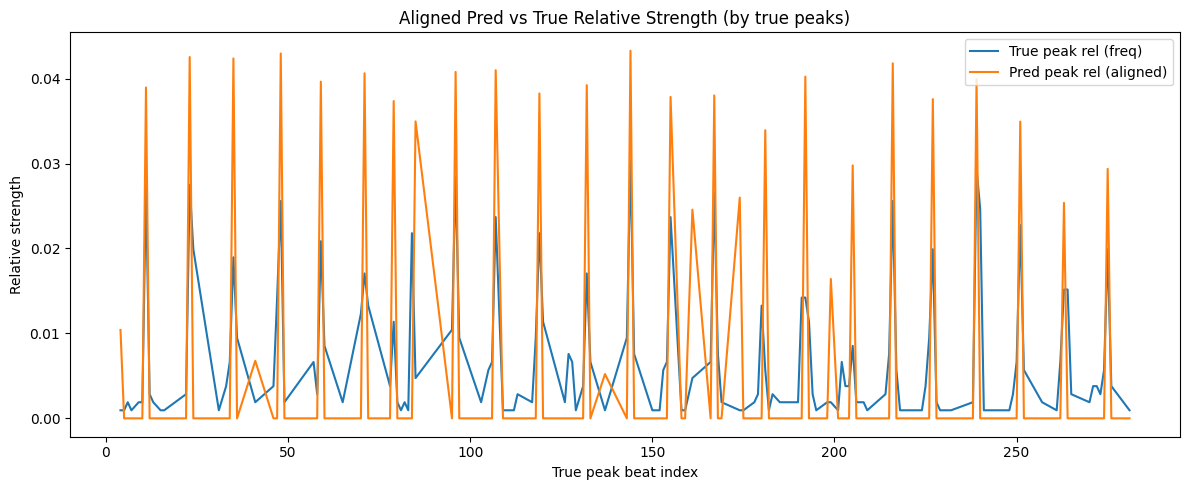

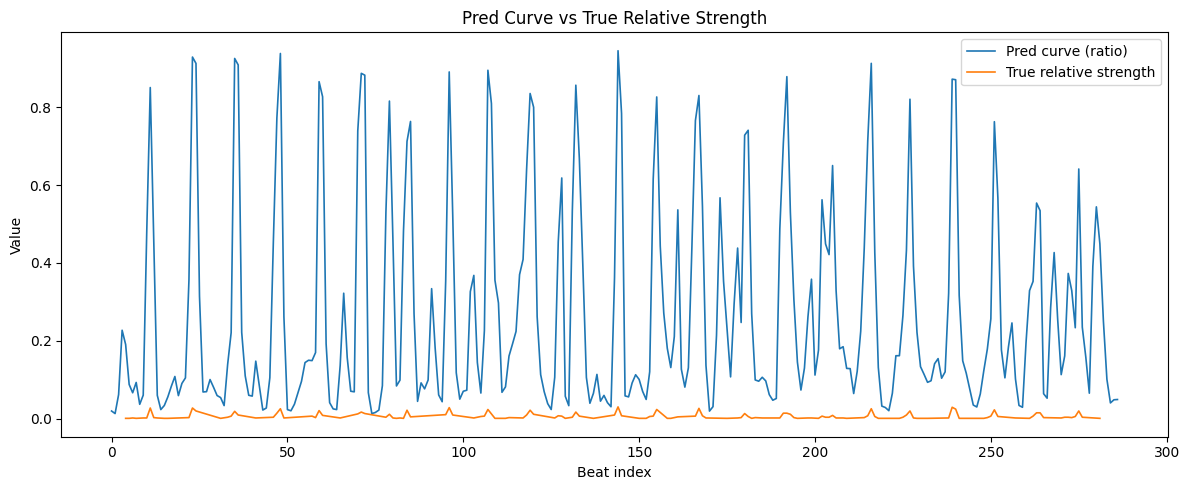

true_avg_peaks: 25.11904761904762 pred_peak_count: 30
pred_peak_strengths_scaled sum: 25.119043840926942
pred_peak_strengths_scaled: [0.26136566 0.97836023 1.06845318 1.06425088 0.17005621 1.07898495
 0.99566548 1.02031099 0.93838383 0.87813846 1.02438331 1.02942957
 0.96073599 0.98532152 0.13088457 1.08713708 0.95058714 0.61702933
 0.9548512  0.6526678  0.85215135 1.01056704 0.41219713 0.74789707
 1.04985566 0.94390041 1.00311457 0.87751337 0.63709132 0.73775851]
pred_peak_positions: [  3  11  23  35  41  48  59  71  79  85  96 107 119 132 138 144 155 161
 167 173 181 192 199 205 216 227 239 251 263 275]


In [67]:
# l2 ratio
result = analyze_boundary_dist(
    config_path = Path("config_beat_mazurka_level2_ratio.yaml"),
    ckpt_path = Path("check/beat_mazurka/level_2/beat_mazurka_L2_20260131_174338/best.pt"),
    input_dir = Path("beat_data_mazurka_performer_levels"),
    pattern="M06-2_*_L2.npz",
    output_head="ratio",
    pred_height=0.05,
    pred_min_dist=6,
    pred_prominence=0.03,
    use_true_binary=use_true_binary,
    true_height=0.05,
    true_min_dist=6,
    true_prominence=0.03,
    assign_radius=6,
    do_plots=True,
)

print("true_avg_peaks:", result["true_avg_peaks"], "pred_peak_count:", result["pred_peak_count"])

if result['pred_peak_strengths_scaled'].size > 0:
    print('pred_peak_strengths_scaled sum:', result['pred_peak_strengths_scaled'].sum())
    print('pred_peak_strengths_scaled:', result['pred_peak_strengths_scaled'])
if result['pred_peak_positions'].size > 0:
    print('pred_peak_positions:', result['pred_peak_positions'])


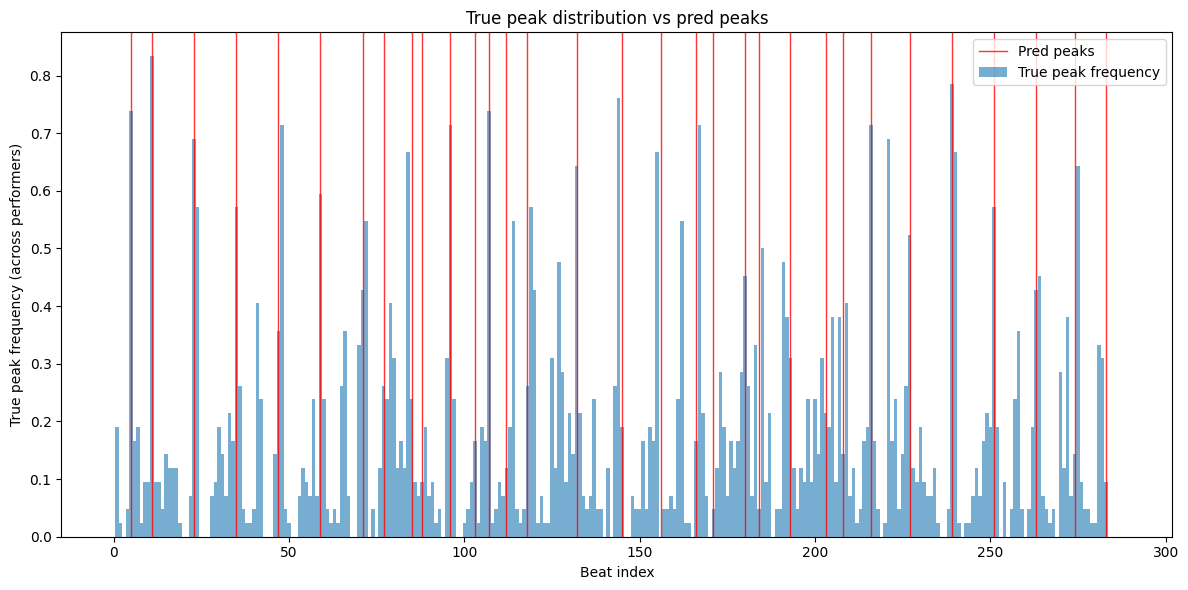

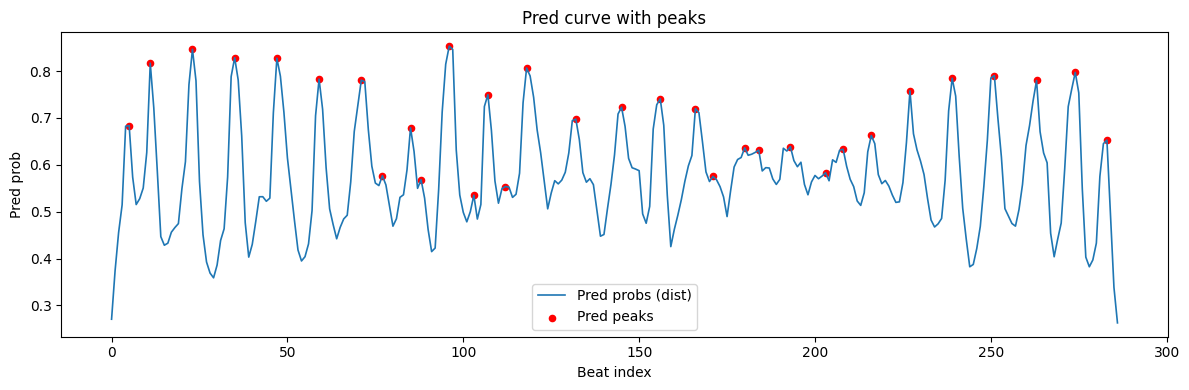

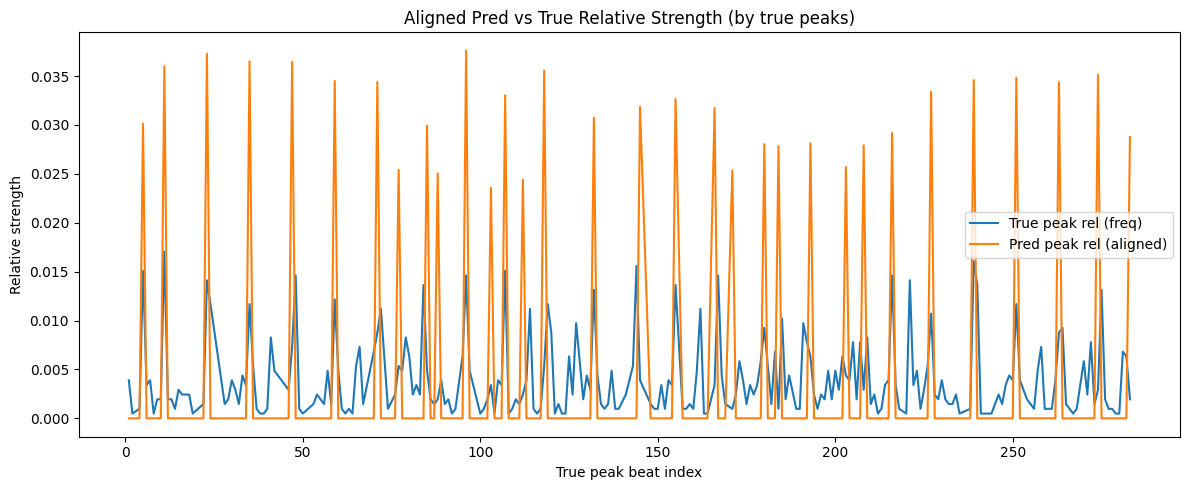

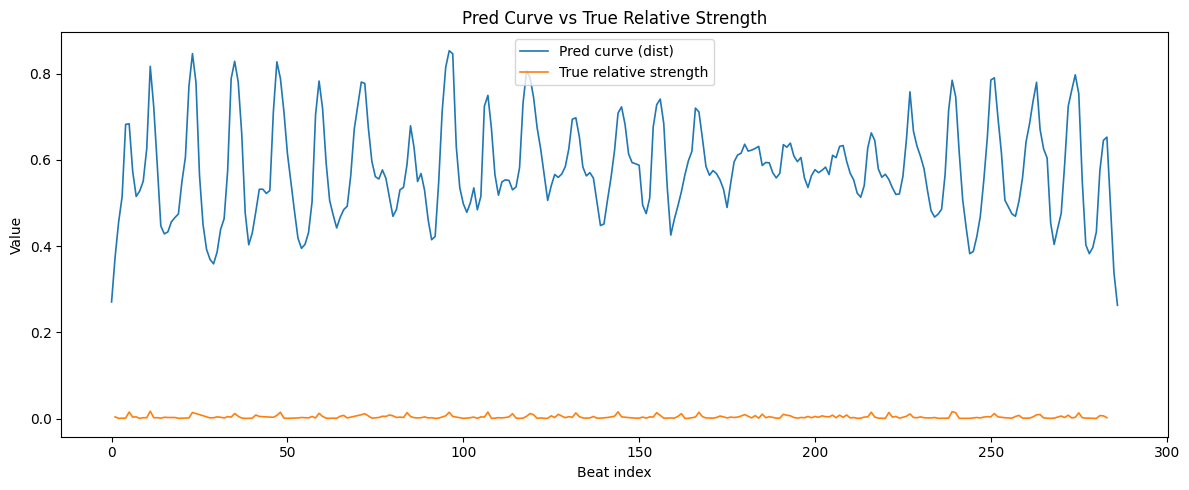

true_avg_peaks: 48.904761904761905 pred_peak_count: 32
pred_peak_strengths_scaled sum: 48.90475862544207
pred_peak_strengths_scaled: [1.47313961 1.76038789 1.82393984 1.78554173 1.78305984 1.68703661
 1.68210288 1.24278151 1.46325045 1.224893   1.83860076 1.15299173
 1.61553396 1.19319956 1.73808651 1.50334242 1.55795967 1.59668334
 1.55176012 1.23956932 1.37118346 1.3605877  1.37673307 1.25664784
 1.36462782 1.42786933 1.63322316 1.691027   1.70320712 1.68091012
 1.71815244 1.40672883]
pred_peak_positions: [  5  11  23  35  47  59  71  77  85  88  96 103 107 112 118 132 145 156
 166 171 180 184 193 203 208 216 227 239 251 263 274 283]


In [68]:
# l1 dist
result = analyze_boundary_dist(
    config_path = Path("config_beat_mazurka_level1.yaml"),
    ckpt_path = Path("check/beat_mazurka/level_1/beat_mazurka_L1_20260131_005320/best.pt"),
    input_dir = Path("beat_data_mazurka_performer_levels"),
    pattern="M06-2_*_L1.npz",
    output_head="dist",
    pred_height=0.01,
    pred_min_dist=1,
    pred_prominence=0.01,
    use_true_binary=use_true_binary,
    true_height=0.05,
    true_min_dist=6,
    true_prominence=0.03,
    assign_radius=6,
    do_plots=True,
)

print("true_avg_peaks:", result["true_avg_peaks"], "pred_peak_count:", result["pred_peak_count"])

if result['pred_peak_strengths_scaled'].size > 0:
    print('pred_peak_strengths_scaled sum:', result['pred_peak_strengths_scaled'].sum())
    print('pred_peak_strengths_scaled:', result['pred_peak_strengths_scaled'])
if result['pred_peak_positions'].size > 0:
    print('pred_peak_positions:', result['pred_peak_positions'])


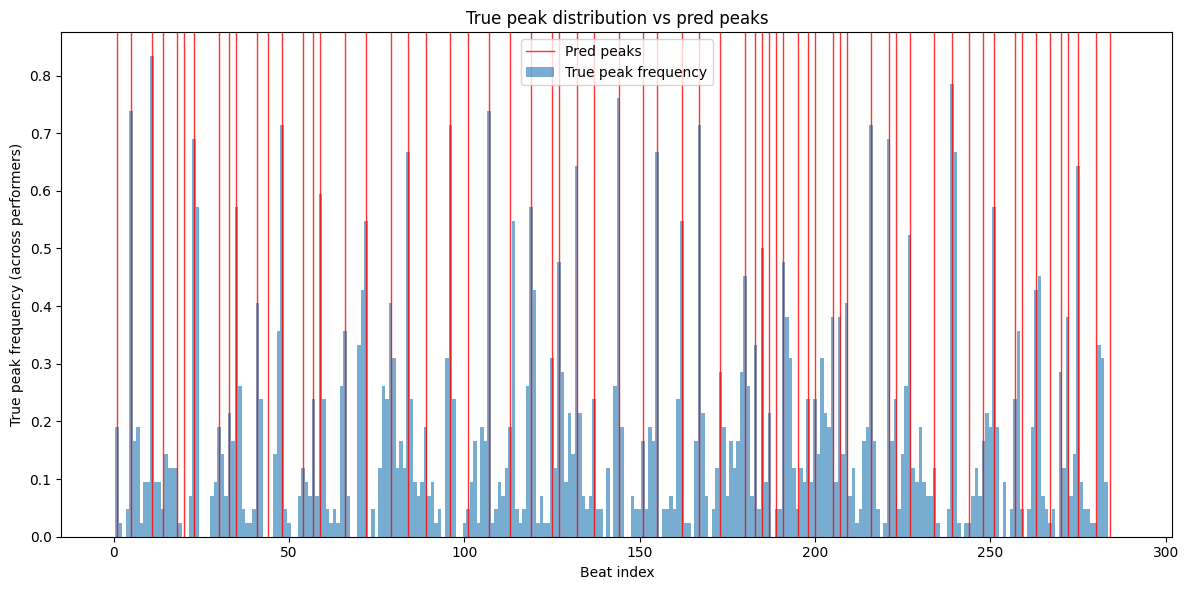

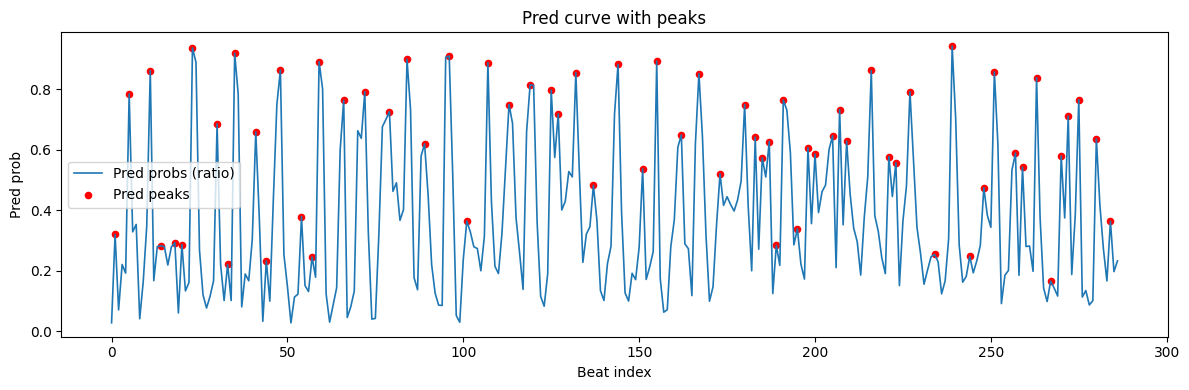

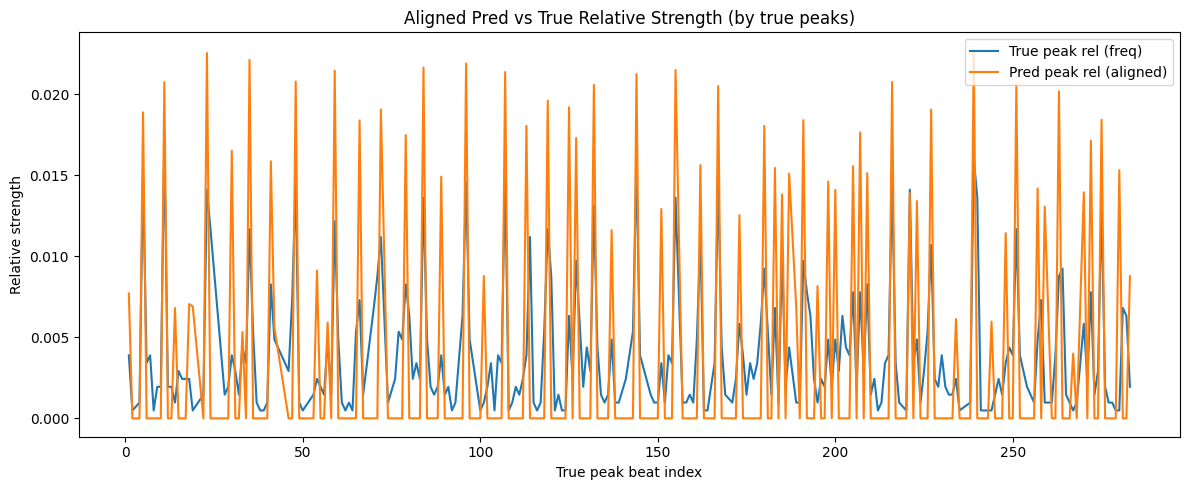

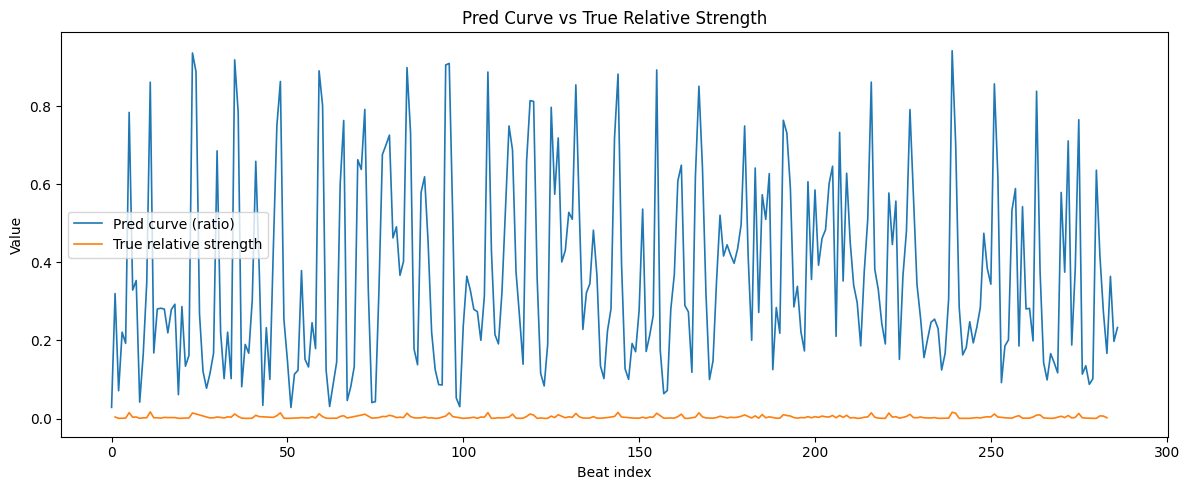

true_avg_peaks: 48.904761904761905 pred_peak_count: 66
pred_peak_strengths_scaled sum: 48.90476062947085
pred_peak_strengths_scaled: [0.37734382 0.9239112  1.01498173 0.33299165 0.34505395 0.33797358
 1.10323105 0.80772963 0.26070914 1.08259147 0.77645758 0.27417455
 1.01733474 0.44645608 0.28925714 1.04946314 0.89951224 0.93280043
 0.855351   1.05922058 0.72966902 1.07176225 0.42968964 1.04568938
 0.88312347 0.95943935 0.93936262 0.84672739 1.00700406 0.56844422
 1.03949101 0.63213813 1.05189021 0.76466169 1.0028989  0.61358716
 0.88308567 0.75612052 0.67549716 0.73915814 0.33512073 0.9001886
 0.39912192 0.71474206 0.68997326 0.76141958 0.86354156 0.74034845
 1.01547181 0.68077177 0.65618566 0.93240008 0.2999188  1.11012145
 0.2921465  0.55917577 1.01019156 0.69417002 0.63948741 0.98778898
 0.19578514 0.682447   0.83792133 0.90171968 0.74955705 0.42905978]
pred_peak_positions: [  1   5  11  14  18  20  23  30  33  35  41  44  48  54  57  59  66  72
  79  84  89  96 101 107 113 119 125

In [72]:
# l1 ratio
result = analyze_boundary_dist(
    config_path = Path("config_beat_mazurka_level1_ratio.yaml"),
    ckpt_path = Path("check/beat_mazurka/level_1/beat_mazurka_L1_20260131_185426/best.pt"),
    input_dir = Path("beat_data_mazurka_performer_levels"),
    pattern="M06-2_*_L1.npz",
    output_head="ratio",
    pred_height=0.03,
    pred_min_dist=2,
    pred_prominence=0.03,
    use_true_binary=use_true_binary,
    true_height=0.05,
    true_min_dist=6,
    true_prominence=0.03,
    assign_radius=6,
    do_plots=True,
)

print("true_avg_peaks:", result["true_avg_peaks"], "pred_peak_count:", result["pred_peak_count"])

if result['pred_peak_strengths_scaled'].size > 0:
    print('pred_peak_strengths_scaled sum:', result['pred_peak_strengths_scaled'].sum())
    print('pred_peak_strengths_scaled:', result['pred_peak_strengths_scaled'])
if result['pred_peak_positions'].size > 0:
    print('pred_peak_positions:', result['pred_peak_positions'])


In [73]:
import csv
piece_id = "M06-2"
input_dir = Path("beat_data_mazurka_performer_levels")

# level -> config & ckpt
levels = {
    1: {
        "config": "config_beat_mazurka_level1_ratio.yaml",
        "ckpt": "check/beat_mazurka/level_1/beat_mazurka_L1_20260131_005320/best.pt",
        "output_head": "ratio",
        "pred_height": 0.03, "pred_min_dist": 2, "pred_prominence": 0.03,
    },
    2: {
        "config": "config_beat_mazurka_level2_ratio.yaml",
        "ckpt": "check/beat_mazurka/level_2/beat_mazurka_L2_20260130_234527/best.pt",
        "output_head": "ratio",
        "pred_height": 0.05, "pred_min_dist": 6, "pred_prominence": 0.03,
    },
    3: {
        "config": "config_beat_mazurka_level3_ratio.yaml",
        "ckpt": "check/beat_mazurka/level_3/beat_mazurka_L3_20260130_231129/best.pt",
        "output_head": "ratio",
        "pred_height": 0.05, "pred_min_dist": 6, "pred_prominence": 0.03,
    },
    4: {
        "config": "config_beat_mazurka_level4.yaml",
        "ckpt": "check/beat_mazurka/level_4/beat_mazurka_L4_20260130_190213/best.pt",
        "output_head": "dist",
        "pred_height": 0.03, "pred_min_dist": 3, "pred_prominence": 0.01,
    },
    5: {
        "config": "config_beat_mazurka_level5.yaml",
        "ckpt": "check/beat_mazurka/level_5/beat_mazurka_L5_20260130_190152/best.pt",
        "output_head": "dist",
        "pred_height": 0.03, "pred_min_dist": 3, "pred_prominence": 0.01,
    },
    6: {
        "config": "config_beat_mazurka_level6.yaml",
        "ckpt": "check/beat_mazurka/level_6/beat_mazurka_L6_20260130_141117/best.pt",
        "output_head": "dist",
        "pred_height": 0.03, "pred_min_dist": 3, "pred_prominence": 0.01,
    },
}

# true 峰值参数（如果你不需要 true，可保持默认）
use_true_binary = True
true_height = 0.05
true_min_dist = 6
true_prominence = 0.03
assign_radius = 6

out_csv = Path("out") / f"{piece_id}_all_levels_pred_strengths.csv"
# ===========================

rows = []
for lv, cfg in levels.items():
    result = analyze_boundary_dist(
        config_path=cfg["config"],
        ckpt_path=cfg["ckpt"],
        input_dir=input_dir,
        pattern=f"{piece_id}_*_L{lv}.npz",
        output_head=cfg["output_head"],
        pred_height=cfg["pred_height"],
        pred_min_dist=cfg["pred_min_dist"],
        pred_prominence=cfg["pred_prominence"],
        use_true_binary=use_true_binary,
        true_height=true_height,
        true_min_dist=true_min_dist,
        true_prominence=true_prominence,
        assign_radius=assign_radius,
        do_plots=False,
    )

    pos = result["pred_peak_positions"].astype(int)
    strength = result["pred_peak_strengths_scaled"].astype(float)

    rows.append([
        lv,
        " ".join(map(str, pos.tolist())),
        " ".join(f"{v:.6f}" for v in strength.tolist()),
        len(pos),
        float(strength.sum()) if strength.size > 0 else 0.0,
    ])

with out_csv.open("w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["level", "pred_peak_positions", "pred_peak_strengths_scaled", "count", "sum_strength"])
    w.writerows(rows)

print("saved:", out_csv)

saved: out/M06-2_all_levels_pred_strengths.csv


In [ ]:
# Cell 4: helpers to load avg level signals per piece
from collections import defaultdict

def load_piece_level_avg(piece_id, level):
    files = sorted(data_dir.glob(f"{piece_id}_*_L{level}.npz"))
    if not files:
        return None
    arrs = []
    for f in files:
        arrs.append(np.load(f)['boundary_probs'].astype(float))
    # 对齐长度（取最短）
    min_len = min(a.shape[0] for a in arrs)
    arrs = [a[:min_len] for a in arrs]
    return np.mean(np.stack(arrs, axis=0), axis=0)

def build_piece_levels(piece_id, levels):
    levels_avg = {}
    for lv in levels:
        sig = load_piece_level_avg(piece_id, lv)
        if sig is None:
            return None
        levels_avg[lv] = sig
    # 对齐长度（全部取最短）
    min_len = min(len(v) for v in levels_avg.values())
    for lv in levels_avg:
        levels_avg[lv] = levels_avg[lv][:min_len]
    return levels_avg
